### Imports + load data

In [48]:
import matlab.engine
eng = matlab.engine.start_matlab()

eng.addpath(
    eng.genpath("/Users/daviddejonghe/toolboxes/HMeta-d/Matlab"),
    nargout=0
)

eng.eval("which fit_meta_d_mcmc", nargout=0)
eng.eval("which matjags", nargout=0)
eng.eval("system('which jags')", nargout=0)

/Users/daviddejonghe/toolboxes/HMeta-d/Matlab/fit_meta_d_mcmc.m
/Users/daviddejonghe/toolboxes/HMeta-d/Matlab/matjags.m
/usr/local/bin/jags

ans =

     0



In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
import statsmodels.api as sm
import matplotlib.pyplot as plt

from scipy.stats import norm, ttest_ind
from scipy.optimize import minimize

# --- IDs to keep (paste once here) ---
keep_ids = [
    1109430,1136398,1161576,990377,988880,989613,989614,989638,990171,990502,
    1019534,1019545,1019829,1020003,1020094,1026298,1031230,1056155,1076128,
    1076202,1076245,1076467,1077091,1077672,1077748,1083215,1085767,1086215,
    1086429,1086524,1086722,1087676,1087803,1089279,1089330,1089829,1092255,
    1092315,1096800,1097476,1098724,1098967,1099520,1101067,1107685,1107856,
    1109466,1111115,1112029,1112249,1113314,1114743,1114859,944548,953958,
    954010,954564,957126,957158,958563,958619,959561,961534,965512,966909,
    967485,967866,969340,972471,974295,980324,984514,985216,988163,991011,
    998453,1029483,1029603,1029776,1029858,1030062,1030377,1030394,1030711,
    1031236,1032579,1060694,1071048,1072306,954995,955009,955021,955023,
    955077,955083,955102,955119,955240,955276,955303,955342,955383,955683,
    955984,956021,956352,956553,956843,956927,956993,957089,957167,957953,
    958100,958257,958360,958541,958577,958771,959130,959386,959708,960758,
    960817,961191,961560,961864,963283,964156,966004,966051,967144,967215,
    968578,968792,969242,969364,970091,970214,971440,971577,972235,972410,
    972412,972585,972608,972740,973276,973356,973496,973708,973896,974187,
    975356,977249,977374,978290,979523,979791,981984,982296,982316,982404,
    984377,990840,992115,992526,1000003,1002300,1003011,1005185,1055457,
    1055828,1056146,1056537,1057764,1057805,1058277,1058510,1058926,1059194,
    1059249,1059261,1059408,1059911,1060742,1063610,1067860,1069381,1069895,
    1069986,1071196,1071224,1071343,1072006,1072034,1072153,1072208,1074018,
    1074043,1074460,1076254,1077140,1077499,1077520,1077746,1079257,1080555,
    1080861,1081810,1083775,1084292,1084496,1085727,1086436,1087954,1088055,
    1089319,1089331,1089431,1089461,1094362,1094757,1099082,1099754,1100590,
    1102002,1105080,1105574,1106651,1107155,1113140,1113399,1117048,1123812,
    1139756,1164558,982442,982693,983044,983545,983866,983911,984204,984214,
    984218,984230,984337,984798,985205,985936,987475,1005286,1025813,1025854,
    1027427,1028174,1033318,1033745,1039326,1040390,1060306,1066153,1080350,
    1094893,970018,971334,971779,972231,972352,972382,972433,972550,973225,
    973843,974106,974217,974241,974337,974406,974604,974795,975381,975696,
    976140,976152,976614,976932,984212,985153,989292,992393,1000944,1003223,
    1003328,1008892,1008967,1009029,1052583,1059466,1060303,1060654,1061755,
    1066043,1066212,1066462,1066559,1066606,1066734,1068331,1068985,966047,
    969684,969744,969855,970770,973065,973458,1026348,1030251,1030362,1030403,
    1030520,1030648,1031514,1031608,1031873,1032457,1032513,1032530,1032639,
    1033030,1033395,1033397,1033887,1039513,1039632,1039920,1040014,1041483,
    1047104,1054199,1056861,1069540
]

# Use a set for faster membership checks
keep_ids = set(keep_ids)

per = pd.read_csv("Data/PerceptualTaskData.csv")  
sym = pd.read_csv("Data/SymptomData.csv")          

id_col = "IDcode"

# Ensure IDs are comparable (strings vs ints can silently break filtering)
per[id_col] = pd.to_numeric(per[id_col], errors="coerce").astype("Int64")
sym[id_col] = pd.to_numeric(sym[id_col], errors="coerce").astype("Int64")

# Keep only rows where ID is in keep_ids
per = per[per[id_col].isin(keep_ids)].copy()
sym = sym[sym[id_col].isin(keep_ids)].copy()

# Quick sanity checks
print("Unique IDs after filtering:")
print("  Perceptual:", per[id_col].nunique())
print("  Symptom:", sym[id_col].nunique())

# Show first rows
per.head(), sym.head()

Unique IDs after filtering:
  Perceptual: 344
  Symptom: 344


(       IDcode  Age  Sex  Trial  Response  Stimulus  Confidence
 42712  944548   21    0      1         0        24           4
 42713  944548   21    0      2         0       -24           4
 42714  944548   21    0      3         1        32           4
 42715  944548   21    0      4         1        16           3
 42716  944548   21    0      5         0        40           3,
      IDcode  Age  Sex  AnxiousDepression  Compulsivity  SocialWithdrawal
 281  944548   21    0          -0.293255     -0.621615         -0.032964
 282  953958   21    0          -0.566733     -0.123265          0.518405
 283  954010   22    0           1.802008      1.126410         -0.098002
 284  954564   20    0          -0.528183      0.330763         -0.704537
 285  954995   21    0          -0.724605     -0.504122          0.172939)

## Helper code

In [50]:
def mean_sem(x):
    x = x.dropna()
    return x.mean(), x.std(ddof=1) / np.sqrt(len(x))

def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

## D' and criterion c

In [51]:
def loglinear_rate(k,n):
    # Hit and false-alarm rates were corrected using the log-linear rule (Hautus, 1995) to avoid infinite z-scores when proportions equalled 0 or 1.
    return (k + 0.5)/(n + 1)

def compute_dprime_c (stim, resp):
    # stim: signed stimulus, resp: 0/1. We take right as the hit
    sig = stim > 0
    noise = stim < 0

    # Stimulus == 0 can be ignored for SDT rates
    H = resp[sig].sum()
    FA = resp[noise].sum()

    hr  = loglinear_rate(H, sig.sum())
    far = loglinear_rate(FA, noise.sum())

    zH = norm.ppf(hr)
    zF = norm.ppf(far)

    dprime = zH - zF
    c = -0.5 * (zH + zF)
    return dprime, c


## Meta-d' helper function

In [52]:
# Had some help of AI
def counts_for_subject(df, K=6):
    df = df[df["Stimulus"] != 0].copy()
    stim = df["Stimulus"].values
    resp = df["Response"].values
    conf = df["Confidence"].values

    cat = np.empty(len(df), dtype=int)

    # resp=0 => S1 (lef) response: map conf=6 to cat=1 (high), conf=1 naar cat=K (low)
    m0 = resp == 0
    cat[m0] = K - conf[m0] + 1

    # resp=1 => S2 (right) response: map conf=1 to cat=K+1 (low), conf=6 to cat=2K (low)
    m1 = ~m0
    cat[m1] = K + conf[m1]

    S1 = stim < 0
    S2 = stim > 0

    nR_S1 = np.array([(cat[S1] == i).sum() for i in range(1, 2*K + 1)])
    nR_S2 = np.array([(cat[S2] == i).sum() for i in range(1, 2*K + 1)])
    return nR_S1, nR_S2

## Likelihood + optimizer

In [53]:
def metad_negloglik(params, nR_S1, nR_S2, c, K): #Had some help of AI
    meta_d = params[0]

    # enforce monotonically ordered criteria via cumulative positive steps
    s1_steps = np.exp(params[1:K])         # K-1
    s2_steps = np.exp(params[K:2*K-1])     # K-1

    # criteria on evidence axis
    s1_crit = np.sort(c - np.cumsum(s1_steps))  # below c
    s2_crit = np.sort(c + np.cumsum(s2_steps))  # above c

    muS1 = -meta_d / 2
    muS2 =  meta_d / 2

    # Edges for S1 response bins: (-inf ... s1_crit ... c)
    s1_edges = np.concatenate(([-np.inf], s1_crit, [c]))
    # S1-response category probs for a given mu:
    def p_respS1(mu):
        p = norm.cdf(s1_edges[1:], loc=mu) - norm.cdf(s1_edges[:-1], loc=mu)
        return p[::-1]  #  high->low confidence within S1 responses

    # Edges for S2 response bins: (c ... s2_crit ... inf)
    s2_edges = np.concatenate(([c], s2_crit, [np.inf]))
    def p_respS2(mu):
        return norm.cdf(s2_edges[1:], loc=mu) - norm.cdf(s2_edges[:-1], loc=mu)  # low->high within S2 responses

    pS1 = np.concatenate((p_respS1(muS1), p_respS2(muS1)))
    pS2 = np.concatenate((p_respS1(muS2), p_respS2(muS2)))

    eps = 1e-12
    ll = (nR_S1 * np.log(pS1 + eps)).sum() + (nR_S2 * np.log(pS2 + eps)).sum()
    return -ll

def fit_metad(nR_S1, nR_S2, c, K=6): #Had some help of AI
    init = np.zeros(1 + 2*(K-1))
    init[0] = 1
    init[1:] = np.log(0.5)

    bounds = [(1e-3, 6.0)] + [(-5, 5)]*(2*(K-1))

    res = minimize(
        metad_negloglik,
        init,
        args=(nR_S1, nR_S2, c, K),
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 10000}  
    )
    if not res.success:
        return np.nan, None, None, False

    params = res.x
    meta_d = params[0]

    s1_steps = np.exp(params[1:K])
    s2_steps = np.exp(params[K:2*K-1])
    s1_crit = c - np.cumsum(s1_steps)
    s2_crit = c + np.cumsum(s2_steps)

    return meta_d, s1_crit, s2_crit, True

def confidence_criterion_from_criteria(c, s1_crit, s2_crit):
    """
    Benwell-style: |type2_c' - type1_c'| averaged over response sides & criteria.
    Here we approximate type1_c' by c (your SDT criterion) and type2 criteria by the fitted criteria locations.
    Larger value = more conservative / lower confidence bias.
    """
    dist_s1 = np.abs(s1_crit - c)  # K-1
    dist_s2 = np.abs(s2_crit - c)  # K-1
    return np.mean(np.concatenate([dist_s1, dist_s2]))

## D', meta-d', mean confidence merging with symptom dimension

In [54]:
K = 6
rows = []

for pid, dfsub in per.groupby("IDcode"):
    stim = dfsub["Stimulus"].values
    resp = dfsub["Response"].values

    dprime, c = compute_dprime_c(stim, resp)

    nR_S1, nR_S2 = counts_for_subject(dfsub, K = K)
    metad, s1_crit, s2_crit, ok = fit_metad(nR_S1, nR_S2, c, K=K)

    mean_conf = dfsub["Confidence"].mean()

    conf_criterion = np.nan
    if ok and (s1_crit is not None) and (s2_crit is not None):
        conf_criterion = confidence_criterion_from_criteria(c, s1_crit, s2_crit)

    mratio = np.nan
    if ok and np.isfinite(dprime) and (dprime != 0):
        mratio = metad / dprime

    stim = dfsub["Stimulus"].values
    resp = dfsub["Response"].values

    # ignore Stimulus==0 for accuracy
    mask = stim != 0
    acc = np.mean(resp[mask] == (stim[mask] > 0).astype(int))
    
    same_conf = (dfsub["Confidence"].nunique() == 1)

    rows.append({
    "IDcode": pid,
    "accuracy": acc,
    "dprime": dprime,
    "metad": metad if ok else np.nan,
    "mratio": mratio,
    "mean_conf": mean_conf,
    "same_conf": same_conf,
    "conf_criterion": conf_criterion
    })

metrics = pd.DataFrame(rows)

df = (
    metrics.merge(
        sym[["IDcode", "Compulsivity", "AnxiousDepression", "SocialWithdrawal", "Age", "Sex"]],
        on="IDcode",
        how="inner"
    )
    .rename(columns={
        "Compulsivity": "CIT",
        "AnxiousDepression": "AD",
        "SocialWithdrawal": "SW",
        "Age": "age",
        "Sex": "gender"
    })
)

# meta-diff = meta-d' - d' (metacognitive "excess" sensitivity relative to type-1 sensitivity)
df["meta_diff"] = df["metad"] - df["dprime"]

# Create log m-ratio (Benwell uses log(meta-d'/d'))
df["log_mratio"] = np.log(df["mratio"])

# --- Make tertiles again ---
df_comp = df.copy()
df_comp["group"] = pd.qcut(df_comp["CIT"], 3, labels=["low", "mid", "high"])

df_ad = df.copy()
df_ad["group"] = pd.qcut(df_ad["AD"], 3, labels=["low", "mid", "high"])

df_sw = df.copy()
df_sw["group"] = pd.qcut(df_sw["SW"], 3, labels=["low", "mid", "high"])

## Make the barplot

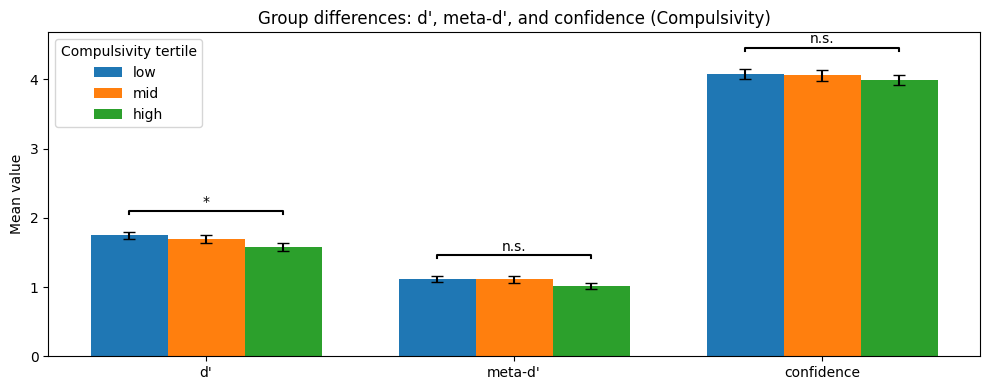

Compulsivity {"d'": (np.float64(0.02668397284472567), '*'), "meta-d'": (np.float64(0.09979644538390496), 'n.s.'), 'confidence': (np.float64(0.3698015344449507), 'n.s.')}


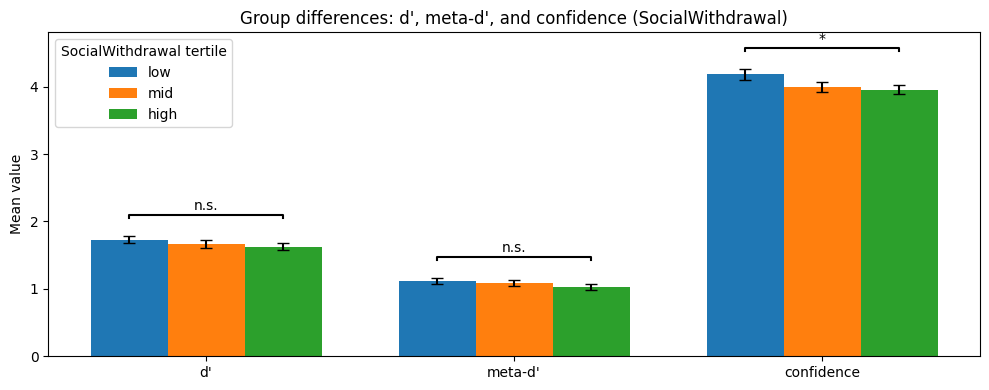

SocialWithdrawal {"d'": (np.float64(0.14783814056581127), 'n.s.'), "meta-d'": (np.float64(0.16343705725067628), 'n.s.'), 'confidence': (np.float64(0.0321846545343284), '*')}


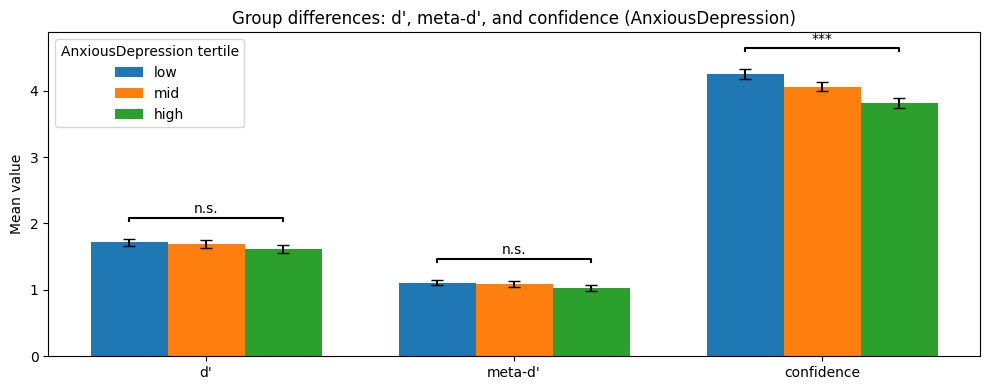

AnxiousDepression {"d'": (np.float64(0.19040505368917288), 'n.s.'), "meta-d'": (np.float64(0.22149153731986382), 'n.s.'), 'confidence': (np.float64(7.877774233235049e-05), '***')}


In [55]:
order = ["low", "mid", "high"]
metrics_to_plot = [("dprime", "d'"), ("metad", "meta-d'"), ("mean_conf", "confidence")]

def plot_tertiles(df, title_suffix, legend_title):
    means = {m: [] for m, _ in metrics_to_plot}
    sems  = {m: [] for m, _ in metrics_to_plot}

    for g in order:
        sub = df[df["group"] == g]
        for m, _ in metrics_to_plot:
            mu, se = mean_sem(sub[m])
            means[m].append(mu)
            sems[m].append(se)

    # significance (high vs low)
    pvals = {}
    for m, _ in metrics_to_plot:
        low_vals  = df[df["group"] == "low"][m].dropna()
        high_vals = df[df["group"] == "high"][m].dropna()
        pvals[m] = ttest_ind(low_vals, high_vals, equal_var=False).pvalue

    # plot
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(metrics_to_plot))
    w = 0.25

    colors = ["tab:blue", "tab:orange", "tab:green"]
    for i, g in enumerate(order):
        vals = [means[m][i] for m, _ in metrics_to_plot]
        err  = [sems[m][i]  for m, _ in metrics_to_plot]
        ax.bar(x + (i-1)*w, vals, width=w, yerr=err, capsize=4,
               color=colors[i], label=g)

    ax.set_xticks(x)
    ax.set_xticklabels([lab for _, lab in metrics_to_plot])
    ax.set_ylabel("Mean value")
    ax.set_title(f"Group differences: d', meta-d', and confidence ({title_suffix})")

    # add stars (low vs high)
    y0, y1 = ax.get_ylim()
    yr = y1 - y0
    for j, (m, _) in enumerate(metrics_to_plot):
        y_max = max(means[m][0] + sems[m][0], means[m][2] + sems[m][2])
        y = y_max + 0.06*yr
        x1 = j - w
        x2 = j + w
        ax.plot([x1, x1, x2, x2], [y, y+0.01*yr, y+0.01*yr, y], lw=1.5, c="black")
        ax.text((x1+x2)/2, y+0.015*yr, stars(pvals[m]), ha="center", va="bottom")

    ax.legend(title=legend_title)
    plt.tight_layout()
    plt.show()

    print(title_suffix, {lab: (pvals[m], stars(pvals[m])) for m, lab in metrics_to_plot})

plot_tertiles(df_comp, "Compulsivity", "Compulsivity tertile")
plot_tertiles(df_sw, "SocialWithdrawal", "SocialWithdrawal tertile")
plot_tertiles(df_ad, "AnxiousDepression", "AnxiousDepression tertile")

## Benwell-style figure


DV: dprime
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.365e-16      0.053  -6.39e-15      1.000      -0.104       0.104
CIT           -0.1516      0.062     -2.451      0.015      -0.273      -0.030
AD             0.0147      0.065      0.226      0.821      -0.113       0.142
SW             0.0429      0.063      0.683      0.495      -0.081       0.167
age            0.0237      0.056      0.423      0.672      -0.086       0.134
gender         0.1815      0.055      3.325      0.001       0.074       0.289

DV: metad
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.082e-16      0.054  -3.88e-15      1.000      -0.105       0.105
CIT           -0.1338      0.063     -2.127      0.034      -0.258      -0.010
AD            -0.0008      0.

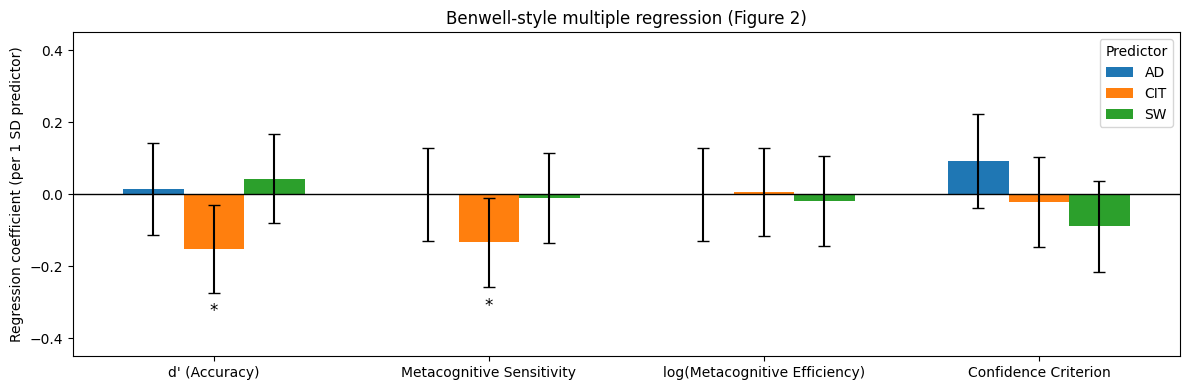

In [56]:
#Ai was used here. First time I did a regression in Python so not sure I did it correctly.
def zscore(s):
    s = s.astype(float)
    return (s - s.mean()) / s.std(ddof=1)

def plot_benwell_fig2(df,
                      dvs=[("dprime","d' (Accuracy)"),
                           ("metad","Metacognitive Sensitivity"),
                           ("log_mratio","log(Metacognitive Efficiency)"),
                           ("conf_criterion","Confidence Criterion")],
                      predictors=("CIT","AD","SW","age","gender"),
                      interest=("AD","CIT","SW"),
                      title="Benwell-style multiple regression (Figure 2)", ylim=(-0.45, 0.45)):
    df = df.copy()

    # z-score regressors (Benwell: z-scores of all regressors)
    for col in ["CIT","AD","SW","age","gender"]:
        if col in df.columns:
            df[col] = zscore(df[col])
            
    # z-score dependent variables
    for dv, _ in dvs:
        if dv in df.columns:
            df[dv] = zscore(df[dv])

    results = {}  # dv -> term -> (beta, lo, hi)

    for dv, _ in dvs:
        sub = df[[dv] + list(predictors)].dropna().copy()
        if len(sub) < 30:
            print(f"Skip {dv}: too few rows ({len(sub)})")
            continue

        X = sm.add_constant(sub[list(predictors)])
        y = sub[dv].astype(float)

        model = sm.OLS(y, X).fit()
        ci = model.conf_int()

        results[dv] = {}
        for term in interest:
            results[dv][term] = {
                "beta": model.params[term],
                "lo":   ci.loc[term, 0],
                "hi":   ci.loc[term, 1],
                "p":    model.pvalues[term],
            }

        print(f"\nDV: {dv}")
        print(model.summary().tables[1])  # coef table

    dv_keys = [dv for dv, _ in dvs if dv in results]
    labels  = [lab for dv, lab in dvs if dv in results]

    x = np.arange(len(dv_keys))
    w = 0.22
    offsets = {"AD": -w, "CIT": 0.0, "SW": +w}

    fig, ax = plt.subplots(figsize=(12, 4))

    for term in ["AD","CIT","SW"]:
        betas = [results[dv][term]["beta"] for dv in dv_keys]
        los   = [results[dv][term]["lo"]   for dv in dv_keys]
        his   = [results[dv][term]["hi"]   for dv in dv_keys]

        yerr = np.vstack([np.array(betas) - np.array(los),
                          np.array(his) - np.array(betas)])

        ax.bar(x + offsets[term], betas, width=w, yerr=yerr, capsize=4, label=term)

        # add significance stars per bar
        for j, dv in enumerate(dv_keys):
            p = results[dv][term]["p"]
            st = stars(p)
            if st == "n.s.":
                continue

            b  = results[dv][term]["beta"]
            lo = results[dv][term]["lo"]
            hi = results[dv][term]["hi"]

            # place star just beyond the CI in the direction of the bar
            if b >= 0:
                y_text = hi + 0.03 * (ylim[1] - ylim[0])
                va = "bottom"
            else:
                y_text = lo - 0.03 * (ylim[1] - ylim[0])
                va = "top"

            ax.text(j + offsets[term], y_text, st, ha="center", va=va, fontsize=12)

    ax.axhline(0, color="black", lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Regression coefficient (per 1 SD predictor)")
    ax.set_title(title)
    ax.legend(title="Predictor")
  

    ax.set_ylim(*ylim)
    ax.set_yticks(np.arange(-0.4, 0.41, 0.2))

    plt.tight_layout()
    plt.show()

plot_benwell_fig2(df)